# Notebook 4 — Predict Unrated Courses and Build the Final Merged Dataset

This notebook fixes the missing-course problem.

Workflow:
1. Identify courses that never appear in `ratings.csv`.
2. Train 3+ regression models on **rated courses only**.
3. Choose the best model using cross-validated RMSE and MAE.
4. Predict ratings for unrated courses.
5. Append predicted rows to `ratings.csv`.
6. Merge with `final_courses.csv`.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

PROJECT_ROOT = Path('..').resolve()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'
MODELS_DIR = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'

sys.path.append(str(PROJECT_ROOT))
import utils_recommender as ur
ur.ensure_dirs(FIGURES_DIR, MODELS_DIR, RESULTS_DIR)

In [2]:
ratings = pd.read_csv(DATA_RAW / 'ratings.csv')
courses = pd.read_csv(DATA_PROCESSED / 'cleaned_courses.csv')
courses = ur.add_num_genres(courses)

rated_df, unrated_df = ur.prepare_regression_dataset(courses, ratings)

print('Rated courses for regression  :', rated_df.shape)
print('Unrated courses for prediction:', unrated_df.shape)

Rated courses for regression  : (126, 19)
Unrated courses for prediction: (181, 19)


In [3]:
regression_results, best_model = ur.evaluate_regressors(rated_df, random_state=42)
regression_results = regression_results.round(4)
regression_results

,Model,CV_MAE,CV_RMSE
0,RandomForest,0.1846,0.3021
1,Ridge,0.2311,0.3115
2,GradientBoosting,0.1797,0.3133
3,LinearRegression,0.3244,0.4239


In [4]:
regression_results.to_csv(RESULTS_DIR / 'results_regression_model_selection.csv', index=False)
print('Saved:', RESULTS_DIR / 'results_regression_model_selection.csv')

Saved: /Users/macbook/Downloads/recommender_full_project/results/results_regression_model_selection.csv


In [5]:
predicted_courses = ur.predict_unrated_courses(best_model, unrated_df)
predicted_courses[['COURSE_ID', 'TITLE', 'predicted_rating']].head(15)

,COURSE_ID,TITLE,predicted_rating
2,GPXX0ZG0EN,consuming restful services using the reactive ...,2.982608
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,2.999773
7,GPXX0FTCEN,learn how to use docker containers for iterati...,2.999675
9,GPXX06RFEN,create your first mongodb database,2.990333
10,GPXX0SDXEN,testing microservices with the arquillian mana...,2.999517
14,GPXX0PICEN,create a cryptocurrency trading algorithm in p...,2.998464
16,GPXX0W7KEN,securing java microservices with eclipse micro...,2.998089
28,GPXX0A1YEN,validating constraints for javabeans in java m...,2.999310
34,GPXX03HFEN,fundamentals of javascript through rock paper ...,2.991825
38,GPXX0IBEN,data science in insurance basic statistical a...,2.367734


In [6]:
predicted_courses.to_csv(DATA_PROCESSED / 'predicted_unrated_courses_with_titles.csv', index=False)
print('Saved:', DATA_PROCESSED / 'predicted_unrated_courses_with_titles.csv')

Saved: /Users/macbook/Downloads/recommender_full_project/data/processed/predicted_unrated_courses_with_titles.csv


In [7]:
predicted_ratings_rows, ratings_full = ur.append_predicted_courses_to_ratings(
    ratings_df=ratings,
    predicted_courses_df=predicted_courses,
    synthetic_user_start=-1
)

ratings_full.to_csv(DATA_PROCESSED / 'ratings_full_with_predictions.csv', index=False)
print('Saved:', DATA_PROCESSED / 'ratings_full_with_predictions.csv')

predicted_ratings_rows.head()

Saved: /Users/macbook/Downloads/recommender_full_project/data/processed/ratings_full_with_predictions.csv


,user,item,rating
0,-1,GPXX0ZG0EN,2.982608
1,-2,GPXX0Z2PEN,2.999773
2,-3,GPXX0FTCEN,2.999675
3,-4,GPXX06RFEN,2.990333
4,-5,GPXX0SDXEN,2.999517


In [8]:
final_merged = ur.merge_courses_and_ratings(courses, ratings_full)
final_merged.to_csv(DATA_PROCESSED / 'final_complete_merged_dataset.csv', index=False)

print('Final merged shape:', final_merged.shape)
print('Unique courses after merge:', final_merged['COURSE_ID'].nunique())
print('Saved:', DATA_PROCESSED / 'final_complete_merged_dataset.csv')

Final merged shape: (233487, 21)
Unique courses after merge: 307
Saved: /Users/macbook/Downloads/recommender_full_project/data/processed/final_complete_merged_dataset.csv


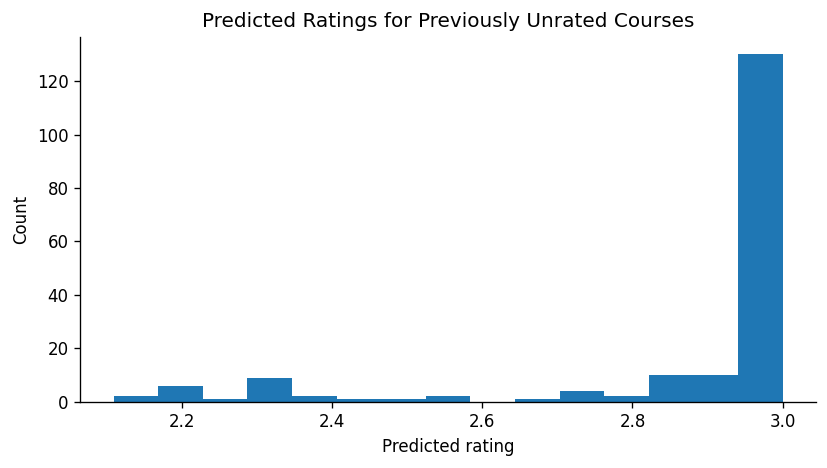

In [9]:
plt.figure(figsize=(7,4))
plt.hist(predicted_courses['predicted_rating'], bins=15)
plt.title('Predicted Ratings for Previously Unrated Courses')
plt.xlabel('Predicted rating')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'predicted_unrated_distribution.png')
plt.show()